In [1]:
################################################################################
# Load dataset and split it into training and test set
################################################################################

import pandas as pd
import os
from tabulate import tabulate

dataset_name = "bot-iot"
sample_size = 100000

# Absolute path to population CSV (outside the notebook directory)
data_path = os.path.join(
    os.path.expanduser("~"),
    "Documents", "Projects", "RAG Paper",
    "data", "bot-iot", "bot-iot-population.csv"
)

df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(f"attack value counts:\n{df['attack'].value_counts()}")

# Split by binary label
normal_df = df[df['attack'] == 0].drop(columns=['attack', 'category', 'subcategory'])
attack_df = df[df['attack'] == 1].drop(columns=['attack', 'category', 'subcategory'])

# Split dataset into training and test set
normal_df_train = normal_df.sample(frac=0.8, random_state=42)
normal_df_test = normal_df.drop(normal_df_train.index)
attack_df_train = attack_df.sample(frac=0.8, random_state=42)
attack_df_test = attack_df.drop(attack_df_train.index)

# Print dataset sizes in a table
data = [
    ["Normal", normal_df.shape[0], normal_df_train.shape[0], normal_df_test.shape[0]],
    ["Attack", attack_df.shape[0], attack_df_train.shape[0], attack_df_test.shape[0]]
]
print(tabulate(data, headers=["Attack type", "Total", "Train", "Test"], tablefmt="grid"))

Loaded 2,934,817 rows, 19 columns
attack value counts:
attack
1    2934447
0        370
Name: count, dtype: int64
+---------------+---------+---------+--------+
| Attack type   |   Total |   Train |   Test |
+===============+=========+=========+========+
| Normal        |     370 |     296 |     74 |
+---------------+---------+---------+--------+
| Attack        | 2934447 | 2347558 | 586889 |
+---------------+---------+---------+--------+


In [2]:
################################################################################
# Vector Store
################################################################################

import json
import numpy as np
from langchain_chroma import Chroma
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

train_set_size = sample_size
n_results = 10
embeddings = HuggingFaceEmbeddings()
vector_store = Chroma(
    collection_name=dataset_name,
    embedding_function=embeddings,
    persist_directory=f"./vector-stores/chroma-db-{train_set_size}-2")

# Auto-populate vector store if empty
_existing_ids = vector_store._collection.get(include=[], where={'label': 'normal'})['ids']
if len(_existing_ids) == 0:
    print("Vector store empty — populating from training data...")
    _vs_n = min(500, len(normal_df_train), len(attack_df_train))
    _normal_sample = normal_df_train.sample(n=_vs_n, random_state=42)
    _attack_sample = attack_df_train.sample(n=_vs_n, random_state=42)
    vector_store.add_texts(
        texts=[json.dumps(row.tolist()) for _, row in _normal_sample.iterrows()],
        metadatas=[{'label': 'normal'}] * _vs_n
    )
    vector_store.add_texts(
        texts=[json.dumps(row.tolist()) for _, row in _attack_sample.iterrows()],
        metadatas=[{'label': 'attack'}] * _vs_n
    )
    print(f"Vector store populated with {_vs_n} normal + {_vs_n} attack documents.")

normal_vectors = vector_store._collection.get(include=['embeddings'], where={'label': 'normal'})['embeddings']
normal_mean_vector = np.mean(normal_vectors, axis=0).tolist()
normal_documents = \
    vector_store._collection.query(query_embeddings=[normal_mean_vector], n_results=n_results)['documents'][0]

attack_vectors = vector_store._collection.get(include=['embeddings'], where={'label': 'attack'})['embeddings']
attack_mean_vector = np.mean(attack_vectors, axis=0).tolist()
attack_documents = \
    vector_store._collection.query(query_embeddings=[attack_mean_vector], n_results=n_results)['documents'][0]

def parse_document(doc):
    try:
        return json.loads(doc)
    except (json.JSONDecodeError, ValueError):
        import ast
        return ast.literal_eval(doc)

feature_names = normal_df_train.columns.to_list()
doc_length = len(parse_document(normal_documents[0]))
valid_features = feature_names[:doc_length]

normal_entries_dict = {}
for i, feature_name in enumerate(valid_features):
    normal_entries_dict[feature_name] = [parse_document(doc)[i] for doc in normal_documents]

attack_doc_length = len(parse_document(attack_documents[0]))
valid_attack_features = feature_names[:attack_doc_length]

attack_entries_dict = {}
for i, feature_name in enumerate(valid_attack_features):
    attack_entries_dict[feature_name] = [parse_document(doc)[i] for doc in attack_documents]

In [3]:
################################################################################
# State
################################################################################

from langgraph.graph import MessagesState


class State(MessagesState):
    i: int

In [4]:
################################################################################
# Policy Evaluate Tool
################################################################################

import operator
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from typing import Annotated
from langchain_core.tools import tool

show_progress = False
operators = {'<': operator.lt, '>': operator.gt, '==': operator.eq, '<=': operator.le, '>=': operator.ge,
              '!=': operator.ne}


@tool
def policy_evaluate_tool(
        feature_name: Annotated[str, "Feature name"],
        value: Annotated[str, "Value"],
        op: Annotated[str, "Operator"]
) -> float:
    """Evaluate the policy and return the macro f1-score."""
    print("PET>", end="")
    try:
        value = float(value)
    except ValueError:
        value
    datasets = {"normal": normal_df_train, "attack": attack_df_train}
    y_pred = []
    y_true = []
    if op in operators:
        for attack_type, dataset in datasets.items():
            test_set_size = dataset.shape[0]
            for i in tqdm(range(test_set_size), ncols=100, desc=f"Predicting {attack_type} entries...",
                          disable=not show_progress):
                y_true.append(attack_type)
                y_pred.append("attack" if operators[op](dataset.iloc[i][feature_name], value) else "normal")
        c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
        return c_report['macro avg']['f1-score']
    else:
        raise ValueError(f"Unsupported operator: {op}")

In [5]:
################################################################################
# Long-term Memory Write Tool
################################################################################

import sqlite3
from typing import List


@tool
def lt_memory_write_tool(policy: List[str]) -> bool:
    """
    Write a policy to the SQL database.

    Args:
        policy (List[str]): ['feature', 'operator', 'value', 'f1_score', 'comment']

    Returns:
        bool: True if the policy is successfully written to the database, False otherwise.
    """
    print("MWT>", end="")
    try:
        # Create a connection to a SQLite database
        db_name = "results/database.db"
        connection = sqlite3.connect(db_name)

        # Write data to the database
        table_name = "lt_memory"
        cursor = connection.cursor()

        # Create the table if it does not exist
        cursor.execute(
            f"CREATE TABLE IF NOT EXISTS {table_name} (feature TEXT  PRIMARY KEY, operator TEXT, value TEXT, f1_score TEXT, comment TEXT)")

        # Insert the policy into the table
        cursor.execute(f"INSERT OR REPLACE INTO {table_name} VALUES (?, ?, ?, ?, ?)",
                       [str(element) for element in policy])

        # Commit the changes
        connection.commit()

        # Close the connection
        connection.close()

        return True
    except Exception as e:
        print(e)
        return False


In [6]:
################################################################################
# Function for retrieving previous policies from Long-term Memory
################################################################################

import sqlite3


def get_previous_policies(as_string=False, filtered=False):
    try:
        # Create a connection to a SQLite database
        db_name = "results/database.db"
        connection = sqlite3.connect(db_name)
        connection.row_factory = sqlite3.Row

        # Read data from the database
        table_name = "lt_memory"
        cursor = connection.cursor()

        # Create the table if it does not exist
        cursor.execute(
            f"CREATE TABLE IF NOT EXISTS {table_name} (feature TEXT PRIMARY KEY, operator TEXT, value TEXT, f1_score TEXT, comment TEXT)")

        # Read the policies from the table
        cursor.execute(f"SELECT * FROM {table_name}")
        rows = cursor.fetchall()

        # Close the connection
        connection.close()

        fetched_policies = [dict(row) for row in rows]

        def safe_float(value):
            try:
                return float(value)
            except (ValueError, TypeError):
                return 0

        try:
            sorted_policies = sorted(fetched_policies, key=lambda x: safe_float(x['f1_score']), reverse=True)
        except Exception as e:
            print(e)
            sorted_policies = fetched_policies

        if as_string:
            str_policies = []
            for sorted_policy in sorted_policies:
                policy = f"Policy: {sorted_policy['feature']} {sorted_policy['operator']} {sorted_policy['value']}, F1-Score: {sorted_policy['f1_score']}, Comment: {sorted_policy['comment']}"
                str_policies.append(policy)
            return "\n".join(str_policies[:k])

        return sorted_policies
    except Exception as e:
        print(e)
        return []

In [7]:
################################################################################
# Function for getting filtered messages
################################################################################

from langchain_core.messages import SystemMessage, HumanMessage
import uuid
import json

normal_entries = json.dumps(normal_entries_dict)
attack_entries = json.dumps(attack_entries_dict)


def get_init_messages(init=False):
    if init:
        system_message = SystemMessage(f"""
        You are a skilled security data analyst. Your task is to generate effective filtering policies to identify attack entries in network data. Follow these steps carefully:

        Input data analysis:
        1. You will receive network data entries labeled as either 'normal' or 'attack,' along with their feature names.
        2. Analyze the key differences between 'normal' and 'attack' entries by comparing feature values.

        Policy generation:
        1. Your goal is to create exactly {k} simple and deterministic policies based on the top {k} important features that can filter out 'attack' entries.
        2. Use only the following operators: >, <, >=, <= for continuous numeric features. You MAY use '==' or '!=' ONLY for categorical or discrete features (e.g., string values, port numbers, protocol types, binary flags).
        3. Policies should be designed so that when a policy evaluates to TRUE, the entry is classified as 'attack'; otherwise, it is classified as 'normal.'

        Evaluation:
        1. Generate a tool call for each policy to test its effectiveness.
        2. Evaluate the performance of each policy and compute the F1-score.

        Output Requirements:
        Finally, only output the complete set of {k} policies along with their corresponding F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
        Below is the network data categorized into 'normal' and 'attack' entries, along with their corresponding feature names. Your task is as follows:

        Policy Generation: Generate {k} policies based on the top {k} important features to filter out 'attack' entries effectively.

        Policy Evaluation: Evaluate each policy using the 'policy_evaluate_tool' by making a tool call for every generated policy.

        Output Requirements: Provide the generated policies along with their corresponding F1-scores.

        Normal Entries:
        ```{json.dumps(normal_entries_dict)}```

        Attack Entries:
        ```{json.dumps(attack_entries_dict)}```
        """, id=str(uuid.uuid4()))
    else:
        system_message = SystemMessage(f"""
        You are a skilled security data analyst. Your task is to generate effective filtering policies to identify attack entries in network data. Follow these steps carefully:

        Input data analysis:
        1. You will receive network data entries labeled as either 'normal' or 'attack,' along with their feature names.
        2. Analyze the key differences between 'normal' and 'attack' entries by comparing feature values.
        3. Additionally, you will be given some knowledge from previously generated policies.

        Policy generation:
        1. Use the previous knowledge as a reference to generate NEW policies, but do not generate the same policies.
        2. Your goal is to create exactly {k} NEW simple and deterministic policies based on the top {k} important features that can filter out 'attack' entries.
        3. Use only the following operators: >, <, >=, <= for continuous numeric features. You MAY use '==' or '!=' ONLY for categorical or discrete features (e.g., string values, port numbers, protocol types, binary flags).
        4. Policies should be designed so that when a policy evaluates to TRUE, the entry is classified as 'attack'; otherwise, it is classified as 'normal'.

        Evaluation:
        1. Generate a tool call for each NEW policy to test its effectiveness.
        2. Make all the tool calls at once.

        Output Requirements:
        Finally, only output the complete set of {k} policies along with their corresponding F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
        Below is the network data categorized into 'normal' and 'attack' entries, along with their corresponding feature names. After that you are given previously generated policies.

        Normal Entries:
        ```
        {json.dumps(normal_entries_dict)}
        ```

        Attack Entries:
        ```
        {json.dumps(attack_entries_dict)}
        ```

        Knowledge:
        ```
        {get_previous_policies(as_string=True)}
        ```

        Your task is as follows:

        Policy Generation: Generate {k} NEW policies based on the top {k} important features to filter out 'attack' entries effectively. You can improve a previously generated policy based on the comment, or create NEW policies using different features.

        Policy Evaluation: Evaluate each policy using the 'policy_evaluate_tool' by making a tool call for every generated policy.

        Output Requirements: Provide the generated policies along with their corresponding F1-scores.
        """, id=str(uuid.uuid4()))
    return [system_message, human_message]

In [8]:
################################################################################
# Policy Generator Node
################################################################################

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic
import dotenv
import os

dotenv.load_dotenv(os.getcwd() + '/../.env')

# OpenAI
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
# llm = ChatOpenAI(model="gpt-4o", temperature=0.1)

# Google Generative AI
# llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", temperature=0.1)
# llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro", temperature=0.1)

# Anthropic
# llm = ChatAnthropic(model="claude-3-5-haiku-latest", temperature=0.1)
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)

# Ollama
# llm = ChatOllama(model="llama3.1:8b", base_url="http://192.168.4.29:11434")

llm_with_policy_evaluate_tool = llm.bind_tools([policy_evaluate_tool])


def policy_generator(state):
    print("PG>", end="")
    if len(state["messages"]) > 0 and isinstance(state["messages"][-1], ToolMessage):
        last_messages = []
        for msg in reversed(state["messages"]):
            last_messages.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_message = llm_with_policy_evaluate_tool.invoke(list(reversed(last_messages)))
        return {"messages": [ai_message]}
    else:
        init_messages = get_init_messages(init=state["i"] == 0)
        ai_message = llm_with_policy_evaluate_tool.invoke(init_messages)
        return {"messages": init_messages + [ai_message]}

In [9]:
################################################################################
# Persistence Filter Node
################################################################################

llm_with_lt_memory_write_tool = llm.bind_tools([lt_memory_write_tool])


def persistence_filter(state):
    print("PF>", end="")
    if len(state["messages"]) > 0 and isinstance(state["messages"][-1], ToolMessage):
        last_messages = []
        for msg in reversed(state["messages"]):
            last_messages.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_message = llm_with_policy_evaluate_tool.invoke(list(reversed(last_messages)))
        return {"messages": [ai_message]}
    else:
        system_message = SystemMessage(f"""
        You are good at comparing values.
        Compare old and new policies with similar feature name based on their performance.
        Your task is to compare and contrast the newly generated policies with the previously generated ones and pick policies with higher f1-score.
        Also, provide insightful comments about their relative strengths and weaknesses.

        Comparison:
        1. For a given feature name, if there is a old policy, compare the f1-score of new policy with the old policy.
        2. If the new policy outperforms the old one, explain why in the comment (e.g., better value ranges, or enhanced conditions).
        3. If the old policy is better, specify what made it more effective in the comment.
        4. Make sure only the policy with the highest F1-score is retained.
        5. If there is no old policy for comparison, use the default comment: "This is the first policy for this feature.".

        Tool Calls to save new policies with the comment:
        1. For each feature, make a tool call to 'lt_memory_write_tool' to insert or replace ONLY top performing policy from old and new.
        2. The tool expects a list of strings: ['feature', 'operator', 'value', 'f1_score', 'comment'].
        3. Make all the tool calls at once after comparing all the policies.

        Example comment:
        "When the value of 'x_count' increased from 0.5 to 0.6, the F1-score improved from 0.8 to 0.9. However, increasing it further to 0.7 caused the F1-score to drop to 0.7. This indicates the optimal range is between 0.5 and 0.6."

        Output Requirements: Finally output the a summary of the new policies in one sentence.
        """, id=str(uuid.uuid4()))
        compound_msg = f"""
        Old Policies:
        ```
        {get_previous_policies(as_string=True)}
        ```

        New Policies:
        ```
        {state["messages"][-1].content}
        ```
        """
        init_messages = [system_message, HumanMessage(compound_msg, id=str(uuid.uuid4()))]
        ai_message = llm_with_lt_memory_write_tool.invoke(init_messages)
        return {"messages": init_messages + [ai_message]}


In [10]:
################################################################################
# Feedback Controller Node
################################################################################

from sklearn.metrics import classification_report, confusion_matrix
from statistics import mode
from tqdm import tqdm


def feedback_controller(state):
    print("FC>")
    sorted_policies = get_previous_policies()
    datasets = {"normal": normal_df_test, "attack": attack_df_test}
    y_pred = []
    y_true = []
    for attack_type, dataset in datasets.items():
        test_set_size = dataset.shape[0]
        for i in tqdm(range(test_set_size), ncols=100, desc=f"Predicting {attack_type} entries...",
                      disable=not show_progress):
            try:
                predicted_attack_types = []
                for policy in sorted_policies[:k]:
                    feature_name = policy['feature']
                    op = policy['operator']
                    value = policy['value']
                    try:
                        value = float(value)
                    except ValueError:
                        value
                    predicted_attack_types.append(
                        "attack" if operators[op](dataset.iloc[i][feature_name], value) else "normal")
                y_true.append(attack_type)
                y_pred.append(mode(predicted_attack_types))
            except Exception as e:
                continue
    c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    c_matrix = confusion_matrix(y_true, y_pred)
    print(c_report['macro avg']['f1-score'])
    print(c_matrix)
    c_reports.append(c_report)
    c_matrices.append(c_matrix)
    return {"i": state["i"] + 1}

In [16]:
################################################################################
# Conditional Edge for Policy Evaluation Tool
################################################################################

def p_eval_conditional_edge(state):
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get("messages", [])):
        ai_message = messages[-1]  # Default case
    elif messages := getattr(state, "messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "policy_evaluate_tool"
    return "persistence_filter"

In [17]:
################################################################################
# Conditional Edge for Policy Evaluation Tool
################################################################################

def lt_mem_conditional_edge(state):
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get("messages", [])):
        ai_message = messages[-1]  # Default case
    elif messages := getattr(state, "messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "lt_memory_write_tool"
    return "feedback_controller"

In [18]:
################################################################################
# Conditional Edge for Feedback
################################################################################

def feedback_conditional_edge(state):
    if state["i"] < n:
        return "policy_generator"
    return "__end__"

In [19]:
################################################################################
# Long-term Memory Cleanup
################################################################################

# Delete all the policies from the database
connection = sqlite3.connect("results/database.db")
cursor = connection.cursor()
cursor.execute("CREATE TABLE IF NOT EXISTS lt_memory (feature TEXT PRIMARY KEY, operator TEXT, value TEXT, f1_score TEXT, comment TEXT)")
cursor.execute("DELETE FROM lt_memory")
connection.commit()

cursor.execute(f"SELECT * FROM lt_memory")
assert len(cursor.fetchall()) == 0

connection.close()


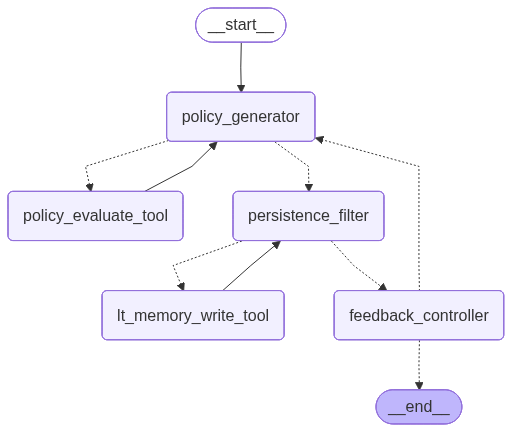

In [20]:
################################################################################
# Graph
################################################################################

from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
def make_tool_node(tools):
    """Custom ToolNode: langgraph.prebuilt.ToolNode unavailable in langgraph 0.2.x."""
    tools_by_name = {t.name: t for t in tools}
    def tool_node(state):
        last_ai_msg = next(
            m for m in reversed(state["messages"])
            if hasattr(m, "tool_calls") and m.tool_calls
        )
        results = []
        for tc in last_ai_msg.tool_calls:
            result = tools_by_name[tc["name"]].invoke(tc["args"])
            results.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
        return {"messages": results}
    return tool_node

builder = StateGraph(State)

builder.add_node("policy_generator", policy_generator)
builder.add_node("policy_evaluate_tool", make_tool_node([policy_evaluate_tool]))
builder.add_node("persistence_filter", persistence_filter)
builder.add_node("lt_memory_write_tool", make_tool_node([lt_memory_write_tool]))
builder.add_node("feedback_controller", feedback_controller)

builder.add_edge(START, "policy_generator")
builder.add_conditional_edges("policy_generator", p_eval_conditional_edge,
                              ["policy_evaluate_tool", "persistence_filter"])
builder.add_edge("policy_evaluate_tool", "policy_generator")
builder.add_conditional_edges("persistence_filter", lt_mem_conditional_edge,
                              ["lt_memory_write_tool", "feedback_controller"])
builder.add_edge("lt_memory_write_tool", "persistence_filter")
builder.add_conditional_edges("feedback_controller", feedback_conditional_edge, ["policy_generator", END])

memory_saver = MemorySaver()
graph = builder.compile(checkpointer=memory_saver, interrupt_before=[])
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
################################################################################
# Invoke Graph
################################################################################

# Configurations
k = 5  # Number of policies
n = 5  # Number of iterations
c_reports = []
c_matrices = []

state = State(i=0, messages=[])
config = {"configurable": {"thread_id": 1}, "recursion_limit": 100}
try:
    output = graph.invoke(state, config)
except Exception as e:
    print(f"Graph stopped early: {e}")

PG>PET>

KeyboardInterrupt: 

In [17]:
################################################################################
# Long-term Memory Visualizer
################################################################################

import datetime

policies = get_previous_policies()
print(tabulate(policies, headers="keys", tablefmt="grid"))

# Save this tabulate table to a file with name as the current timestamp
if len(policies) > 0:
    try:
        llm_name = llm.model_name
    except AttributeError:
        llm_name = llm.model
    llm_name = llm_name.replace("/", "-")
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    file_name = f"results/policies-{timestamp}-{llm_name}.txt"
    with open(file_name, "w") as file:
        file.write(f">>> Results for {llm_name} of sample size {sample_size}\n\n")
        file.write(tabulate(policies, headers="keys", tablefmt="grid"))
        file.write("\n\n")
        for i in range(len(c_reports)):
            file.write(f"{c_reports[i]}\n")
            file.write(f"{c_matrices[i]}\n\n")



+-------------------+------------+---------+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| feature           | operator   |   value |   f1_score | comment                                                                                                                                                                                                                                                                            |
+===================+============+=========+============+=================================================================================================================================================================================================================================================================================

## Complex Policy Generation — Ranges, Disjunctions & Derived Features

The cells below extend the pipeline with **expressive boolean expression** policies that go beyond simple single-threshold rules. Each policy is a Python-evaluable string supporting:

| Type | Example |
|---|---|
| **Range** | `5 < flow_duration < 1000` |
| **Disjunction (OR)** | `dport == 80 or dport == 443` |
| **Derived / ratio** | `N_IN_Conn_P_DstIP / (N_IN_Conn_P_SrcIP + 1) > 5` |
| **Combined** | `(0 < srate < 0.5) and (dport != 53)` |

The LLM is explicitly prompted to prefer these forms, giving it a structural advantage over DT/RF rules which are limited to one feature ≥/≤ threshold per node.


In [22]:
################################################################################
# Complex Policy Evaluate Tool + Long-term Memory (expression-based)
################################################################################

import math
import sqlite3
from typing import Annotated, List
from langchain_core.tools import tool
from tqdm import tqdm
from sklearn.metrics import classification_report

# Safe namespace for eval — no builtins, only explicit math helpers
safe_builtins = {
    "abs": abs, "max": max, "min": min, "round": round,
    "log": math.log, "log2": math.log2, "sqrt": math.sqrt, "exp": math.exp,
}
_cx_globals = {"__builtins__": {}, **safe_builtins}


@tool
def complex_policy_evaluate_tool(
    expression: Annotated[str, (
        "A Python boolean expression using feature names as variables. "
        "Supports ranges ('5 < flow_duration < 1000'), OR conditions ('dport == 80 or dport == 443'), "
        "derived features ('bytes_in / (bytes_out + 1) > 5'), and combinations. "
        "Evaluates to True → attack, False → normal."
    )]
) -> float:
    """Evaluate a complex boolean expression policy and return macro F1-score."""
    print("CPET>", end="")
    datasets = {"normal": normal_df_train, "attack": attack_df_train}
    y_pred, y_true = [], []
    for attack_type, dataset in datasets.items():
        for i in tqdm(range(dataset.shape[0]), ncols=100, desc=f"Predicting {attack_type}...",
                      disable=not show_progress):
            row = dataset.iloc[i].to_dict()
            try:
                result = bool(eval(expression, _cx_globals, row))
            except Exception:
                result = False
            y_pred.append("attack" if result else "normal")
            y_true.append(attack_type)
    c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    return c_report["macro avg"]["f1-score"]


@tool
def complex_lt_memory_write_tool(policy: List[str]) -> bool:
    """
    Write a complex policy expression to the SQL database.
    Args:
        policy (List[str]): ['expression', 'f1_score', 'comment']
    """
    print("CMWT>", end="")
    try:
        conn = sqlite3.connect("results/database.db")
        cur = conn.cursor()
        cur.execute(
            "CREATE TABLE IF NOT EXISTS complex_lt_memory "
            "(expression TEXT PRIMARY KEY, f1_score TEXT, comment TEXT)"
        )
        cur.execute("INSERT OR REPLACE INTO complex_lt_memory VALUES (?, ?, ?)",
                    [str(e) for e in policy])
        conn.commit()
        conn.close()
        return True
    except Exception as e:
        print(e)
        return False


def get_previous_complex_policies(as_string=False):
    try:
        conn = sqlite3.connect("results/database.db")
        conn.row_factory = sqlite3.Row
        cur = conn.cursor()
        cur.execute(
            "CREATE TABLE IF NOT EXISTS complex_lt_memory "
            "(expression TEXT PRIMARY KEY, f1_score TEXT, comment TEXT)"
        )
        cur.execute("SELECT * FROM complex_lt_memory")
        rows = [dict(r) for r in cur.fetchall()]
        conn.close()

        def _f(v):
            try:
                return float(v)
            except Exception:
                return 0.0

        rows = sorted(rows, key=lambda x: _f(x["f1_score"]), reverse=True)
        if as_string:
            return "\n".join(
                f"Expression: {p['expression']}, F1: {p['f1_score']}, Comment: {p['comment']}"
                for p in rows[:k]
            )
        return rows
    except Exception as e:
        print(e)
        return []


# Prompt

In [23]:
################################################################################
# Complex Policy Prompt — encourages ranges, disjunctions, derived features
################################################################################

import json
import uuid
from langchain_core.messages import SystemMessage, HumanMessage

_EXPRESSION_EXAMPLES = (
    "EXPRESSION TYPES — prefer these over simple 'feature > value' rules:\n"
    "  Range:    5 < flow_duration < 1000\n"
    "  OR:       dport == 80 or dport == 443\n"
    "  Derived:  N_IN_Conn_P_DstIP / (N_IN_Conn_P_SrcIP + 1) > 5\n"
    "  Ratio:    seq / (stddev + 1) > 1000\n"
    "  Combined: (0 < srate < 0.5) and (dport != 53)\n"
)


def get_complex_init_messages(init=False):
    if init:
        system_message = SystemMessage(f"""
You are a skilled security data analyst generating EXPRESSIVE Python boolean expressions as filtering policies
to identify attack entries in network traffic data.

{_EXPRESSION_EXAMPLES}

Rules:
- Each expression is evaluated per network row: TRUE → 'attack', FALSE → 'normal'.
- Generate exactly {k} expressions. Strongly prefer ranges, OR conditions, and derived/ratio features
  over simple single-threshold rules (e.g., avoid 'feature > value' alone).
- All Python operators are supported: +, -, *, /, <, >, ==, !=, and, or, not, parentheses.
- Evaluate each expression with 'complex_policy_evaluate_tool' (one tool call per expression).

Output: The complete set of {k} expressions with their F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
Analyse the key differences between 'normal' and 'attack' entries below, then generate {k} expressive
boolean expressions that best distinguish attack traffic.

Normal Entries:
```{json.dumps(normal_entries_dict)}```

Attack Entries:
```{json.dumps(attack_entries_dict)}```

Prefer ranges, disjunctions, and derived ratios. Evaluate each with 'complex_policy_evaluate_tool'.
        """, id=str(uuid.uuid4()))
    else:
        system_message = SystemMessage(f"""
You are a skilled security data analyst. Generate {k} NEW expressive Python boolean expressions to
identify attack entries in network data.

{_EXPRESSION_EXAMPLES}

Rules:
- Do NOT repeat any previously generated expression.
- Build on previous knowledge: explore nearby thresholds, widen/narrow ranges, combine features.
- Strongly prefer range conditions, OR disjunctions, and derived ratio features over simple thresholds.
- Evaluate each new expression with 'complex_policy_evaluate_tool'.

Output: The complete set of {k} NEW expressions with their F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
Normal Entries:
```{json.dumps(normal_entries_dict)}```

Attack Entries:
```{json.dumps(attack_entries_dict)}```

Previous Policies (do NOT repeat — use as reference to explore variations):
```
{get_previous_complex_policies(as_string=True)}
```

Generate {k} NEW expressive boolean expressions (ranges, OR conditions, derived ratios).
Evaluate each with 'complex_policy_evaluate_tool'.
        """, id=str(uuid.uuid4()))
    return [system_message, human_message]


# 20 - Node+Edges

In [24]:
################################################################################
# Complex Graph Nodes and Conditional Edges
################################################################################

from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from sklearn.metrics import classification_report, confusion_matrix
from statistics import mode
from tqdm import tqdm

llm_with_complex_eval_tool = llm.bind_tools([complex_policy_evaluate_tool])
llm_with_complex_lt_write_tool = llm.bind_tools([complex_lt_memory_write_tool])


def complex_policy_generator(state):
    print("CPG>", end="")
    if state["messages"] and isinstance(state["messages"][-1], ToolMessage):
        last_msgs = []
        for msg in reversed(state["messages"]):
            last_msgs.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_msg = llm_with_complex_eval_tool.invoke(list(reversed(last_msgs)))
        return {"messages": [ai_msg]}
    else:
        init_msgs = get_complex_init_messages(init=state["i"] == 0)
        ai_msg = llm_with_complex_eval_tool.invoke(init_msgs)
        return {"messages": init_msgs + [ai_msg]}


def complex_persistence_filter(state):
    print("CPF>", end="")
    if state["messages"] and isinstance(state["messages"][-1], ToolMessage):
        last_msgs = []
        for msg in reversed(state["messages"]):
            last_msgs.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_msg = llm_with_complex_lt_write_tool.invoke(list(reversed(last_msgs)))
        return {"messages": [ai_msg]}
    else:
        sys_msg = SystemMessage(f"""
You compare complex policy expressions by F1-score and retain the best ones.

Rules:
1. For expressions covering the same primary feature or concept, keep the one with the highest F1.
2. Prioritise range/OR/derived expressions over simple single-threshold ones with equal or better F1.
3. Write a comment noting the expression type advantage (e.g., "Range outperforms simple threshold by 0.03").
4. Call 'complex_lt_memory_write_tool' for each policy to save: ['expression', 'f1_score', 'comment'].
5. Make all tool calls at once.

Output: One-sentence summary of retained policies.
        """, id=str(uuid.uuid4()))
        compound = f"""
Old Policies:
```
{get_previous_complex_policies(as_string=True)}
```

New Policies:
```
{state["messages"][-1].content}
```
        """
        msgs = [sys_msg, HumanMessage(compound, id=str(uuid.uuid4()))]
        ai_msg = llm_with_complex_lt_write_tool.invoke(msgs)
        return {"messages": msgs + [ai_msg]}


def complex_feedback_controller(state):
    print("CFC>")
    sorted_policies = get_previous_complex_policies()[:k]
    datasets = {"normal": normal_df_test, "attack": attack_df_test}
    y_pred, y_true = [], []
    for attack_type, dataset in datasets.items():
        for i in tqdm(range(dataset.shape[0]), ncols=100, desc=f"Predicting {attack_type}...",
                      disable=not show_progress):
            row = dataset.iloc[i].to_dict()
            try:
                votes = []
                for policy in sorted_policies:
                    try:
                        result = bool(eval(policy["expression"], _cx_globals, row))
                    except Exception:
                        result = False
                    votes.append("attack" if result else "normal")
                y_pred.append(mode(votes))
            except Exception:
                y_pred.append("normal")
            y_true.append(attack_type)
    c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    c_matrix = confusion_matrix(y_true, y_pred)
    print(c_report["macro avg"]["f1-score"])
    print(c_matrix)
    c_reports_cx.append(c_report)
    c_matrices_cx.append(c_matrix)
    return {"i": state["i"] + 1}


def _cx_last_ai_msg(state):
    if isinstance(state, list):
        return state[-1]
    messages = state.get("messages", []) if isinstance(state, dict) else getattr(state, "messages", [])
    if not messages:
        raise ValueError(f"No messages found in state: {state}")
    return messages[-1]


def complex_p_eval_conditional_edge(state):
    msg = _cx_last_ai_msg(state)
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        return "complex_policy_evaluate_tool"
    return "complex_persistence_filter"


def complex_lt_mem_conditional_edge(state):
    msg = _cx_last_ai_msg(state)
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        return "complex_lt_memory_write_tool"
    return "complex_feedback_controller"


def complex_feedback_conditional_edge(state):
    return "complex_policy_generator" if state["i"] < n else "__end__"


# 21 - Build + Run

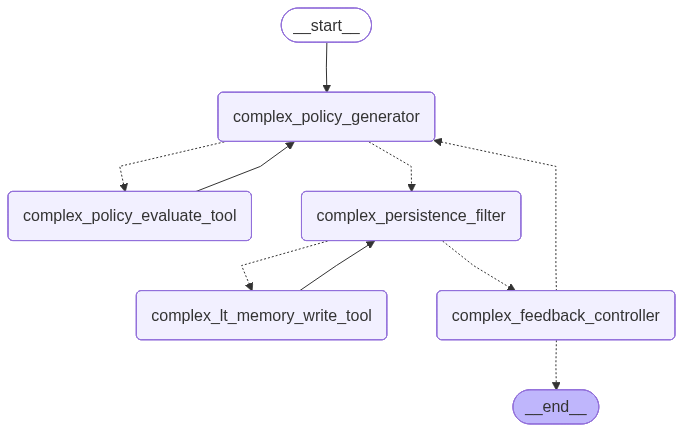

CPG>CPET>

/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

CPET>CPET>CPET>

/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

CPET>CPG>CPF>CMWT>CMWT>CMWT>CPF>CFC>
0.28459558542319685
[[233231 353658]
 [     0     74]]
CPG>CPET>

/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

CPET>CPET>CPET>CPET>CPG>CPET>CPET>CPET>CPET>CPET>CPG>Graph stopped early: Error code: 529 - {'type': 'error', 'error': {'type': 'overloaded_error', 'message': 'Overloaded'}, 'request_id': 'req_011Cb9Rqt7SuRejEzcGj8Y8A'}
+---------------------------------------------------------------------------------+------------+------------------------------------------------------------------------------------------------------------------------------+
| expression                                                                      |   f1_score | comment                                                                                                                      |
+=================================================================================+============+==============================================================================================================================+
| (srate > 0.2) and (mean > 1.3) and (dport != 53)                                |     0.3945 | Best perfor

In [25]:
################################################################################
# Complex Graph — DB cleanup, build, run, and visualize results
################################################################################

from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
import datetime

# Reset complex policies table and result accumulators
_conn = sqlite3.connect("results/database.db")
_cur = _conn.cursor()
_cur.execute("CREATE TABLE IF NOT EXISTS complex_lt_memory (expression TEXT PRIMARY KEY, f1_score TEXT, comment TEXT)")
_cur.execute("DELETE FROM complex_lt_memory")
_conn.commit()
assert len(_cur.execute("SELECT * FROM complex_lt_memory").fetchall()) == 0
_conn.close()

c_reports_cx = []
c_matrices_cx = []

# Build graph
builder_cx = StateGraph(State)
builder_cx.add_node("complex_policy_generator", complex_policy_generator)
builder_cx.add_node("complex_policy_evaluate_tool", make_tool_node([complex_policy_evaluate_tool]))
builder_cx.add_node("complex_persistence_filter", complex_persistence_filter)
builder_cx.add_node("complex_lt_memory_write_tool", make_tool_node([complex_lt_memory_write_tool]))
builder_cx.add_node("complex_feedback_controller", complex_feedback_controller)

builder_cx.add_edge(START, "complex_policy_generator")
builder_cx.add_conditional_edges("complex_policy_generator", complex_p_eval_conditional_edge,
                                  ["complex_policy_evaluate_tool", "complex_persistence_filter"])
builder_cx.add_edge("complex_policy_evaluate_tool", "complex_policy_generator")
builder_cx.add_conditional_edges("complex_persistence_filter", complex_lt_mem_conditional_edge,
                                  ["complex_lt_memory_write_tool", "complex_feedback_controller"])
builder_cx.add_edge("complex_lt_memory_write_tool", "complex_persistence_filter")
builder_cx.add_conditional_edges("complex_feedback_controller", complex_feedback_conditional_edge,
                                  ["complex_policy_generator", END])

memory_saver_cx = MemorySaver()
graph_cx = builder_cx.compile(checkpointer=memory_saver_cx)
display(Image(graph_cx.get_graph().draw_mermaid_png()))

# Run (reuses k and n from earlier cells)
state_cx = State(i=0, messages=[])
config_cx = {"configurable": {"thread_id": 2}, "recursion_limit": 200}
try:
    output_cx = graph_cx.invoke(state_cx, config_cx)
except Exception as e:
    print(f"Graph stopped early: {e}")

# Visualize retained complex policies
cx_policies = get_previous_complex_policies()
print(tabulate(cx_policies, headers="keys", tablefmt="grid"))

if cx_policies:
    try:
        llm_name = llm.model_name
    except AttributeError:
        llm_name = llm.model
    llm_name = llm_name.replace("/", "-")
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    fname = f"results/complex-policies-{timestamp}-{llm_name}.txt"
    with open(fname, "w") as f:
        f.write(f">>> Complex results for {llm_name}, sample size {sample_size}\n\n")
        f.write(tabulate(cx_policies, headers="keys", tablefmt="grid"))
        f.write("\n\n")
        for i, (rep, mat) in enumerate(zip(c_reports_cx, c_matrices_cx)):
            f.write(f"Iteration {i + 1}:\n{rep}\n{mat}\n\n")
    print(f"Saved to {fname}")
